<a href="https://colab.research.google.com/github/faiq191/PCVK_2026/blob/main/latihan_integrasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

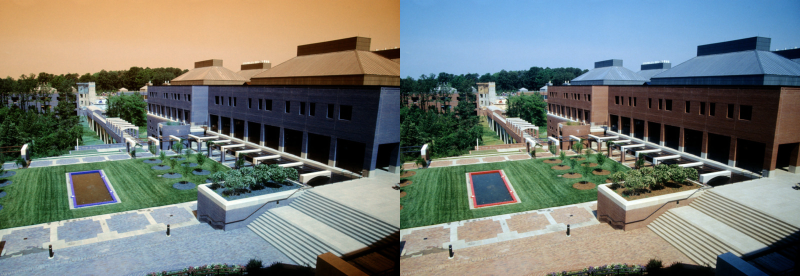

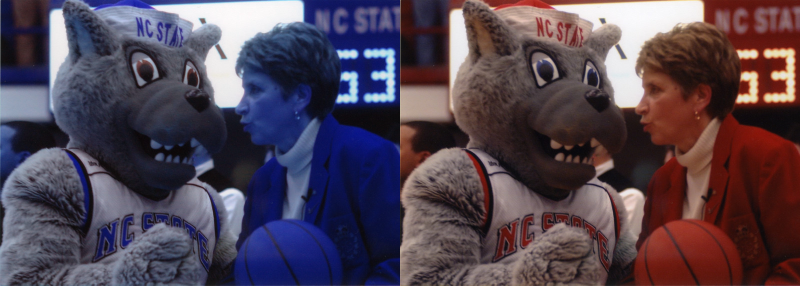

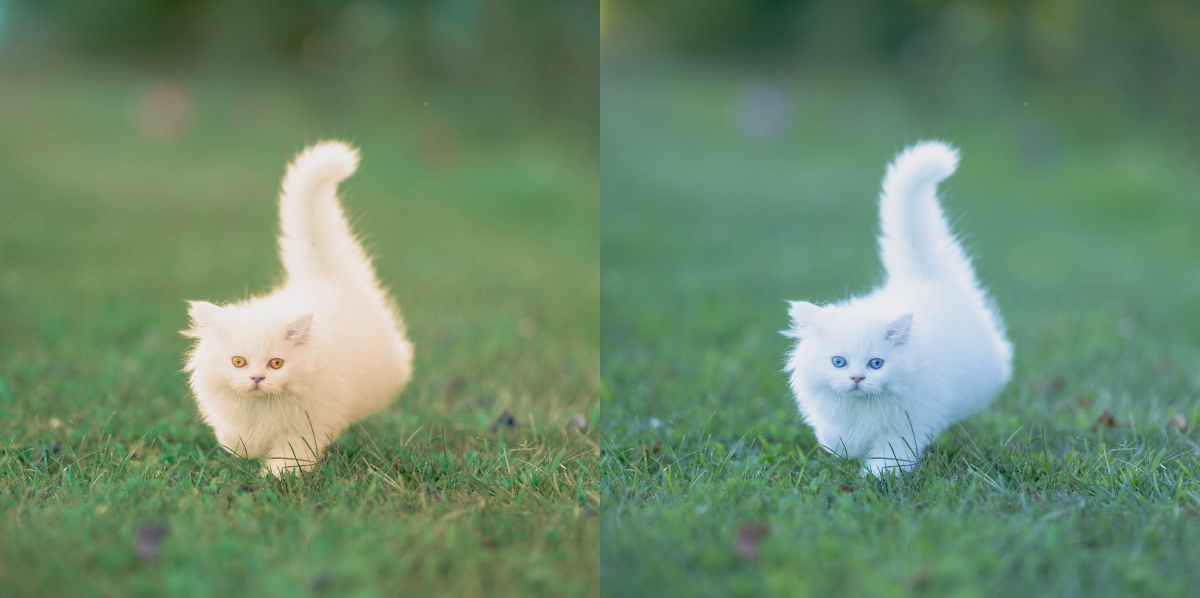



resolusi image: tinggi x lebar =  598  x  600


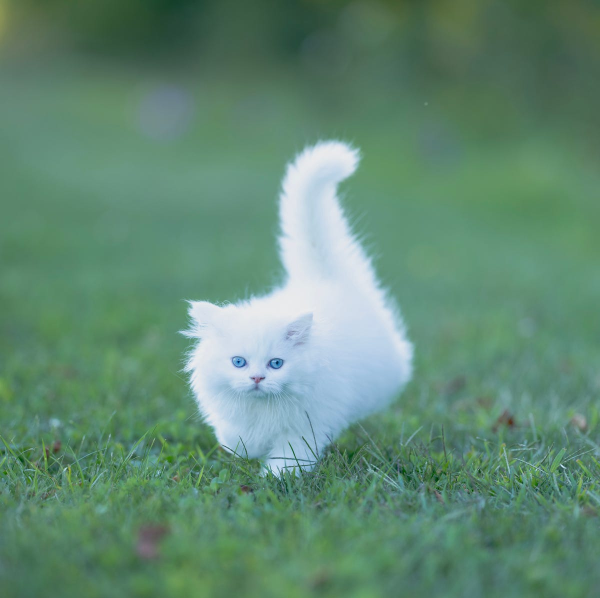

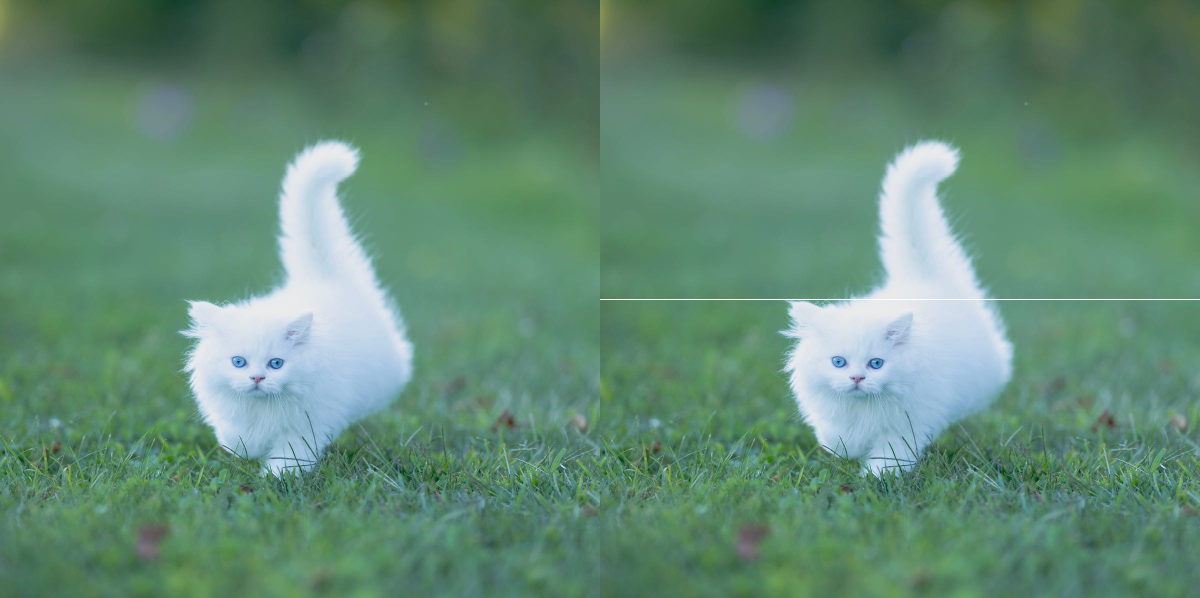

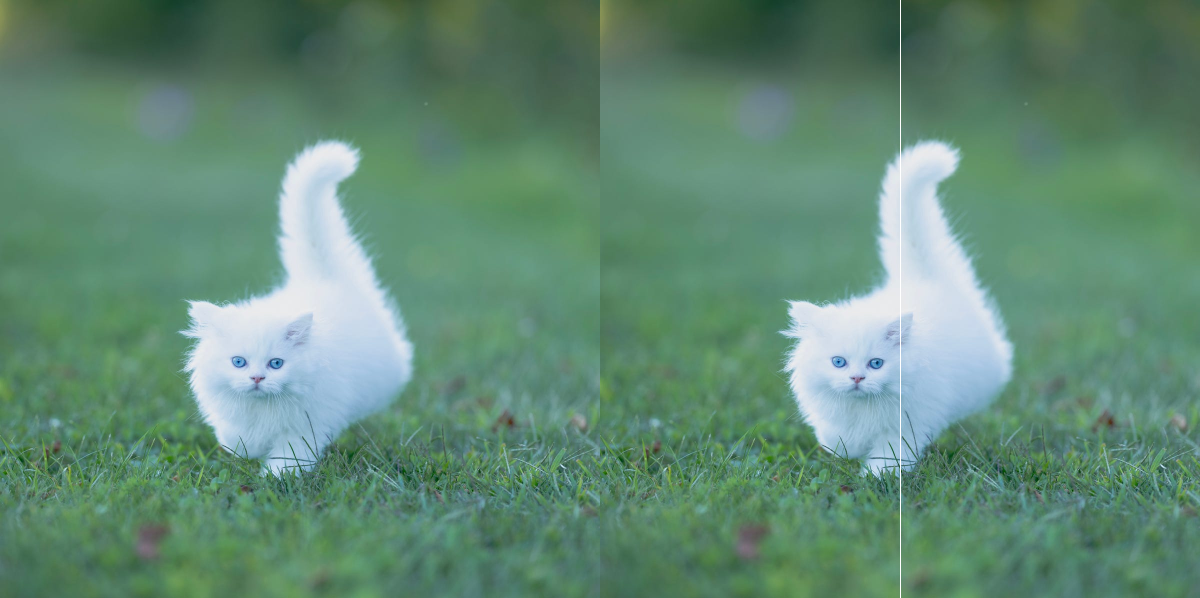

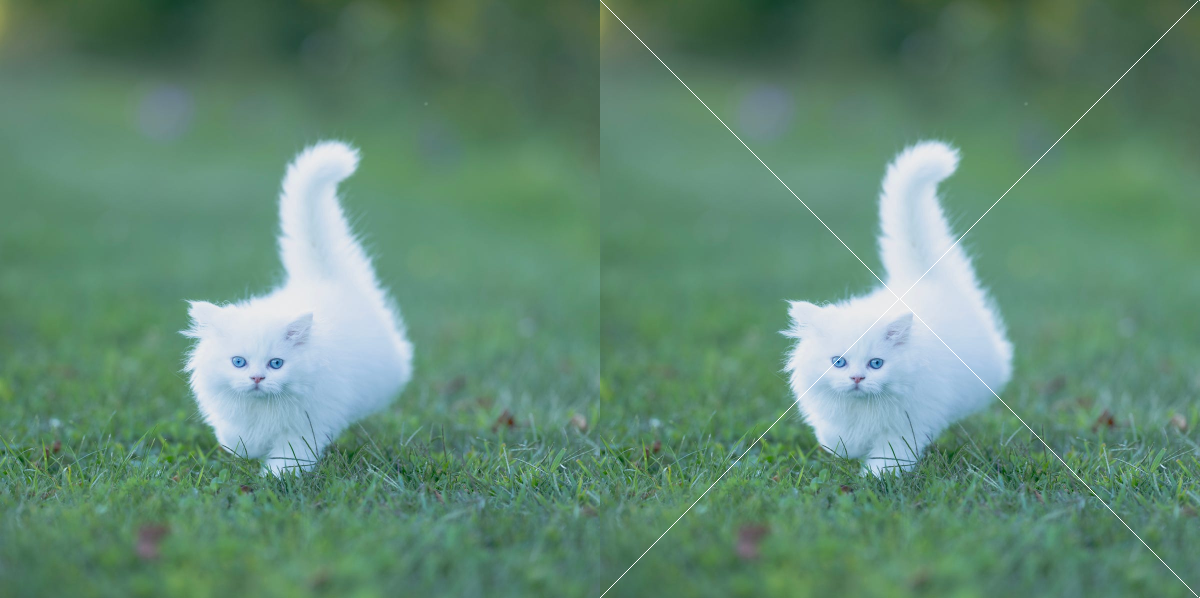

In [9]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

# Membuat list untuk menyimpan url dari beberapa image
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://hips.hearstapps.com/hmg-prod/images/white-cat-breeds-kitten-in-grass-67bf648a54a3b.jpg?crop=0.668xw:1.00xh;0.167xw,0&resize=1200:*"]
# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in urls:
  image = io.imread(url)                     #read image
  image = cv.resize(image, (0,0), fx=0.5, fy=0.5) #resize image to half size
  image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)  #convert color to RGB
  final_frame = cv.hconcat((image, image_2))     #concatenate image
  cv2_imshow(final_frame)                        #show image
  print('\n')

  tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ",tinggi," x ",lebar)
cv2_imshow(image_2)

image_3 = image_2.copy()

#membuat garis horizontal ditengah image
for y in range (lebar):
  image_3[int((tinggi)/2),y] = [255,255,255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

# Reset gambar baru
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Membuat garis vertikal di tengah image
for x in range(tinggi):
  image_3[x, int(lebar / 2)] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

# Reset gambar baru
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = image_2.copy()

# Membuat garis silang (diagonal)
for x in range(tinggi):
    # Hitung posisi y secara proporsional sesuai rasio tinggi dan lebar
    y1 = int(x * (lebar - 1) / (tinggi - 1))       # Diagonal kiri-atas ke kanan-bawah
    y2 = int((tinggi - 1 - x) * (lebar - 1) / (tinggi - 1)) # Diagonal kiri-bawah ke kanan-atas

    image_3[x, y1] = [255, 255, 255]
    image_3[x, y2] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)